#### This notebook demonstrates the use of InFoRM algorithms to mitigate bias for LINE embedding
InFoRM includes 3 algorithms, namely debiasing the input graph, debiasing the mining model and debiasing the mining result. We will show how to run all 3 algorithms for LINE in this notebook.

### Get vanilla embedding matrix first

In [1]:
# load necessary packages
import os, pickle
import load_graph, utils
import numpy as np
import networkx as nx
import sklearn.preprocessing as skpp
from tqdm import tqdm

os.makedirs('result/line', exist_ok=True)
os.makedirs('result/line/graph', exist_ok=True)
os.makedirs('result/line/model', exist_ok=True)
os.makedirs('result/line/result', exist_ok=True)
print('Packages loaded.')

Packages loaded.


In [2]:
# from vanilla_line import *
class LINE:
    def __init__(self, dimension=128, ratio=3200, negative=5,
                 batch_size=1000, init_lr=0.025, seed=None):
        self.dimension  = dimension
        self.ratio      = ratio
        self.negative   = negative
        self.batch_size = batch_size
        self.init_lr    = init_lr
        if seed is not None:
            np.random.seed(seed)

    def train(self, graph):
        self.graph       = graph
        self.is_directed = nx.is_directed(graph)
        self.num_node    = graph.number_of_nodes()
        self.num_sampling_edge = self.ratio * self.num_node

        node2id = {node: vid for vid, node in enumerate(graph.nodes())}
        self.edges = [[node2id[e[0]], node2id[e[1]]] for e in graph.edges()]

        # FIX: 'weight' must be a string key
        self.edges_prob = np.asarray([graph[u][v].get('weight', 1.0) for u, v in graph.edges()])
        self.edges_prob /= np.sum(self.edges_prob)
        self.edges_table, self.edges_prob = alias_setup(self.edges_prob)

        degree_weight = np.zeros(self.num_node)
        for u, v in graph.edges():
            degree_weight[node2id[u]] += graph[u][v].get('weight', 1.0)  # FIX
            if not self.is_directed:
                degree_weight[node2id[v]] += graph[u][v].get('weight', 1.0)  # FIX
        self.node_prob  = np.power(degree_weight, 0.75)
        self.node_prob /= np.sum(self.node_prob)
        self.node_table, self.node_prob = alias_setup(self.node_prob)

        self.emb_vertex = (np.random.random((self.num_node, self.dimension)) - 0.5) / self.dimension
        self._train_line()
        self.embeddings = skpp.normalize(self.emb_vertex, 'l2')  # FIX: string 'l2'
        return self.embeddings

    def _update(self, vec_u, vec_v, vec_error, label):
        f = 1 / (1 + np.exp(-np.sum(vec_u * vec_v, axis=1)))
        g = (self.lr * (label - f)).reshape((len(label), 1))
        vec_error += g * vec_v
        vec_v     += g * vec_u

    def _train_line(self):
        self.lr    = self.init_lr
        batch_size = self.batch_size
        num_batch  = int(self.num_sampling_edge / batch_size)
        # FIX: dùng tqdm thay vì print thủ công
        for b in tqdm(range(num_batch), desc='Training LINE'):
            self.lr = self.init_lr * max((1 - b / num_batch), 0.0001)
            u, v    = [0]*batch_size, [0]*batch_size
            for i in range(batch_size):
                edge_id = alias_draw(self.edges_table, self.edges_prob)
                u[i], v[i] = self.edges[edge_id]
                if not self.is_directed and np.random.rand() > 0.5:
                    v[i], u[i] = self.edges[edge_id]
            vec_error = np.zeros((batch_size, self.dimension))
            label     = np.asarray([1]*batch_size)
            target    = np.asarray(v)
            for j in range(self.negative + 1):
                if j != 0:
                    label = np.zeros(batch_size, dtype=int)
                    for i in range(batch_size):
                        target[i] = alias_draw(self.node_table, self.node_prob)
                self._update(self.emb_vertex[u], self.emb_vertex[target], vec_error, label)
            self.emb_vertex[u] += vec_error

print('LINE class ready.')


def alias_setup(probs):
    K = len(probs)
    q = np.zeros(K)
    J = np.zeros(K, dtype=np.int64)   # FIX: np.int is deprecated → np.int64
    smaller, larger = [], []
    for kk, prob in enumerate(probs):
        q[kk] = K * prob
        if q[kk] < 1.0: smaller.append(kk)
        else:            larger.append(kk)
    while smaller and larger:
        small, large = smaller.pop(), larger.pop()
        J[small] = large
        q[large] = q[large] + q[small] - 1.0
        if q[large] < 1.0: smaller.append(large)
        else:               larger.append(large)
    return J, q

def alias_draw(J, q):
    K  = len(J)
    kk = int(np.floor(np.random.rand() * K))
    return kk if np.random.rand() < q[kk] else J[kk]

LINE class ready.


In [3]:
def vanilla(name, ratio=3200, seed=0):
    try:
        with open('result/line/vanilla.pickle', 'rb') as f:
            edict = pickle.load(f)
    except:
        edict = dict()

    data      = load_graph.read_pickle(name)
    adj_train = data['adjacency_train']
    graph     = nx.from_scipy_sparse_array(adj_train, create_using=nx.Graph(), edge_attribute='weight')

    print(f'Training vanilla LINE on [{name}]...')
    model        = LINE(ratio=ratio, seed=seed)
    edict[name]  = model.train(graph)

    with open('result/line/vanilla.pickle', 'wb') as f:
        pickle.dump(edict, f, protocol=pickle.HIGHEST_PROTOCOL)
    print('Saved: result/line/vanilla.pickle')

In [4]:
vanilla(name='ppi', ratio=3200, seed=0)

Training vanilla LINE on [ppi]...


Training LINE: 100%|██████████| 12448/12448 [08:05<00:00, 25.62it/s] 

Saved: result/line/vanilla.pickle


### Let's debias the input graph

In [5]:
# load debias model
from method.debias_graph import DebiasGraph

In [6]:
def debias_input_graph(name, alpha=0., lr=0., metric=None):
    # load dataset
    data = load_graph.read_pickle(name)
    init_adj = data['adjacency_train']

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(init_adj, metric=metric), sigma=0.75)

    # debias LINE
    FairGraph = DebiasGraph()
    adj = FairGraph.line(init_adj, sim, alpha, maxiter=100, lr=lr, tol=1e-6)
    graph = nx.from_scipy_sparse_array(adj, create_using=nx.Graph(), edge_attribute='weight')
    model = LINE(ratio=3200, seed=0)
    embs = model.train(graph)

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return embs

In [7]:
# jaccard index
result = dict()
result['ppi'] = debias_input_graph('ppi', alpha=10, lr=0.025, metric='jaccard')
with open('result/line/graph/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_input_graph('ppi', alpha=10, lr=0.025, metric='cosine')
with open('result/line/graph/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

Debiasing Graph (LINE):   3%|▎         | 3/100 [00:49<26:17, 16.26s/it]

Training LINE: 100%|██████████| 12448/12448 [05:59<00:00, 34.65it/s] 


dataset: ppi	metric: jaccard similarity
Finished!


Training LINE: 100%|██████████| 12448/12448 [05:51<00:00, 35.46it/s] 


dataset: ppi	metric: cosine similarity
Finished!


### Let's debias the mining model

In [8]:
# load debias model
from method.debias_model import DebiasModel

In [9]:
def debias_mining_model(name, alpha=0., metric=None):
    # load dataset
    data = load_graph.read_pickle(name)
    adj_train = data['adjacency_train']
    graph = nx.from_scipy_sparse_array(adj_train, create_using=nx.Graph(), edge_attribute='weight')

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(adj_train, metric=metric), sigma=0.75)

    # debias LINE
    FairModel = DebiasModel()
    embs = FairModel.line(
        graph, sim, alpha,
        dimension=128, ratio=3200, negative=5,
        init_lr=0.025, batch_size=1000, seed=0
    )

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print('Finished!')

    return embs

In [10]:
alpha = 0.5
# jaccard index
result = dict()
result['ppi'] = debias_mining_model(name='ppi', alpha=alpha, metric='jaccard')
with open('result/line/model/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_mining_model(name='ppi', alpha=alpha, metric='cosine')
with open('result/line/model/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

dataset: ppi	metric: jaccard similarity
Finished!
dataset: ppi	metric: cosine similarity
Finished!


### Let's debias the mining result

In [11]:
# load debias model
from method.debias_result import DebiasResult

In [12]:
def debias_mining_result(name, vanilla, alpha=0., metric=None):
    # vanilla embeddings
    embs = vanilla[name]

    # load dataset
    data = load_graph.read_pickle(name)
    adj_train = data['adjacency_train']

    # build similarity matrix
    sim = utils.filter_similarity_matrix(utils.get_similarity_matrix(adj_train, metric=metric), sigma=0.75)

    # debias LINE
    FairResult = DebiasResult()
    embs = FairResult.fit(embs, sim, alpha)

    print('dataset: {}\tmetric: {} similarity'.format(name, metric))
    print()

    return embs

In [13]:
alpha = 0.5
with open('result/line/vanilla.pickle', 'rb') as f:
    vanilla = pickle.load(f)

# jaccard index
result = dict()
result['ppi'] = debias_mining_result(name='ppi', vanilla=vanilla, alpha=alpha, metric='jaccard')
with open('result/line/result/jaccard.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

# cosine similarity    
result = dict()
result['ppi'] = debias_mining_result(name='ppi', vanilla=vanilla, alpha=alpha, metric='cosine')
with open('result/line/result/cosine.pickle', 'wb') as f:
    pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)

dataset: ppi	metric: jaccard similarity

dataset: ppi	metric: cosine similarity



### Now, let's see how much we debiased and how good debiased results are

In [14]:
# load evaluation functions
from evaluate.line import evaluate

In [15]:
evaluate(name='ppi', metric='jaccard', task='graph')
evaluate(name='ppi', metric='cosine', task='graph')
evaluate(name='ppi', metric='jaccard', task='model')
evaluate(name='ppi', metric='cosine', task='model')
evaluate(name='ppi', metric='jaccard', task='result')
evaluate(name='ppi', metric='cosine', task='result')

{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(0.5617400281155259), 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.6846211122584346)), 'f1': (0.6178672863413375, 0.6183836819003357), 'bias': {'train': [np.float64(0.013210910247969498)], 'validation': [np.float64(0.050172009961849784)], 'test': [np.float64(0.04592758567435329)]}}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.6137951918916235), 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.6811699419384993)), 'f1': (0.6178672863413375, 0.6186418796798347), 'bias': {'train': [np.float64(0.013729562891324543)], 'validation': [np.float64(0.06332448481234332)], 'test': [np.float64(0.054794282348973655)]}}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.23823116757757382), 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.7154187140657258)), '

{'dataset': 'ppi',
 'metric': 'cosine similarity',
 'task': 'debias the mining result',
 'diff': np.float64(0.7220286242529989),
 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.6343595445079172)),
 'f1': (0.6178672863413375, 0.5886909372579395),
 'bias': {'train': [np.float64(0.9704553846367419)],
  'validation': [np.float64(0.9582539132147206)],
  'test': [np.float64(0.9627412770400949)]}}

{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the input graph', 'diff': np.float64(0.5617400281155259), 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.6846211122584346)), 'f1': (0.6178672863413375, 0.6183836819003357), 'bias': {'train': [np.float64(0.013210910247969498)], 'validation': [np.float64(0.050172009961849784)], 'test': [np.float64(0.04592758567435329)]}}
{'dataset': 'ppi', 'metric': 'cosine similarity', 'task': 'debias the input graph', 'diff': np.float64(0.6137951918916235), 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.6811699419384993)), 'f1': (0.6178672863413375, 0.6186418796798347), 'bias': {'train': [np.float64(0.013729562891324543)], 'validation': [np.float64(0.06332448481234332)], 'test': [np.float64(0.054794282348973655)]}}
{'dataset': 'ppi', 'metric': 'jaccard similarity', 'task': 'debias the mining model', 'diff': np.float64(0.23823116757757382), 'roc-auc': (np.float64(0.6818451361318293), np.float64(0.7154187140657258)), '

,task,metric,diff,roc-auc,f1,bias,label
0,graph,jaccard,0.561740,0.684621,0.618384,0.045928,graph-jaccard
1,graph,cosine,0.613795,0.681170,0.618642,0.054794,graph-cosine
2,model,jaccard,0.238231,0.715419,0.642396,0.264472,model-jaccard
3,model,cosine,0.417515,0.740128,0.669249,0.349736,model-cosine
4,result,jaccard,0.507761,0.713288,0.642396,0.870592,result-jaccard
5,result,cosine,0.722029,0.634360,0.588691,0.962741,result-cosine


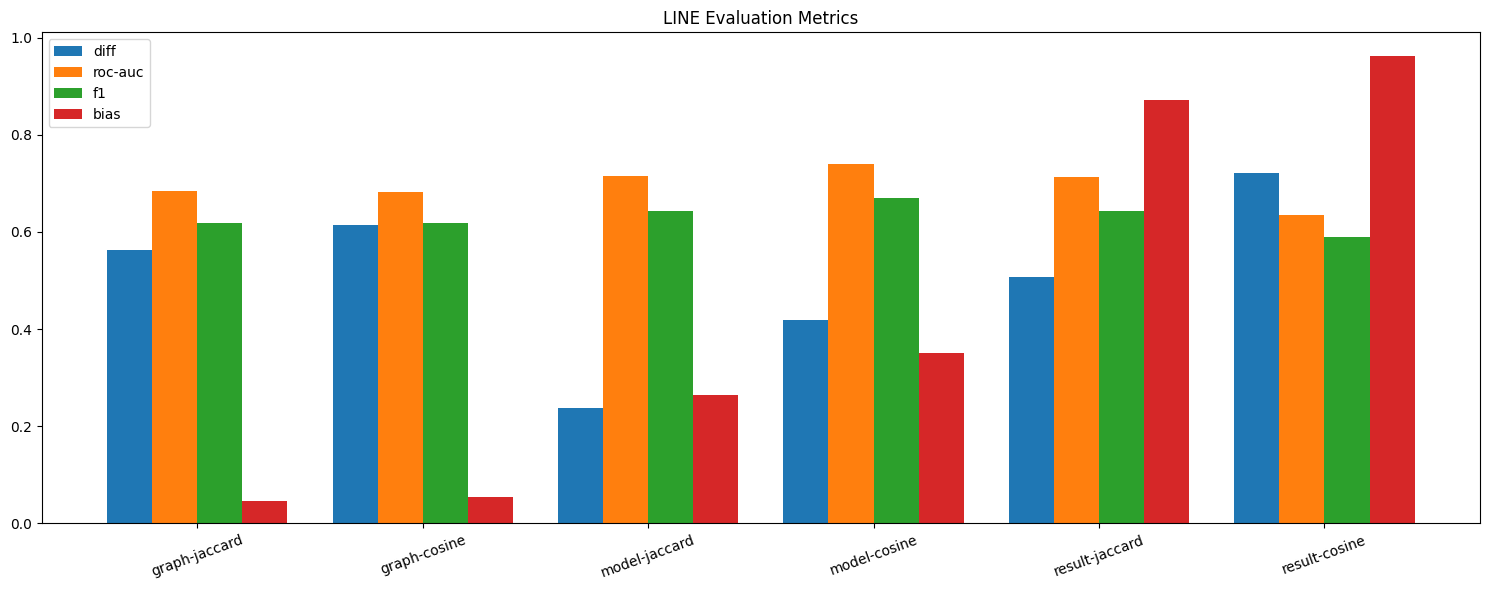

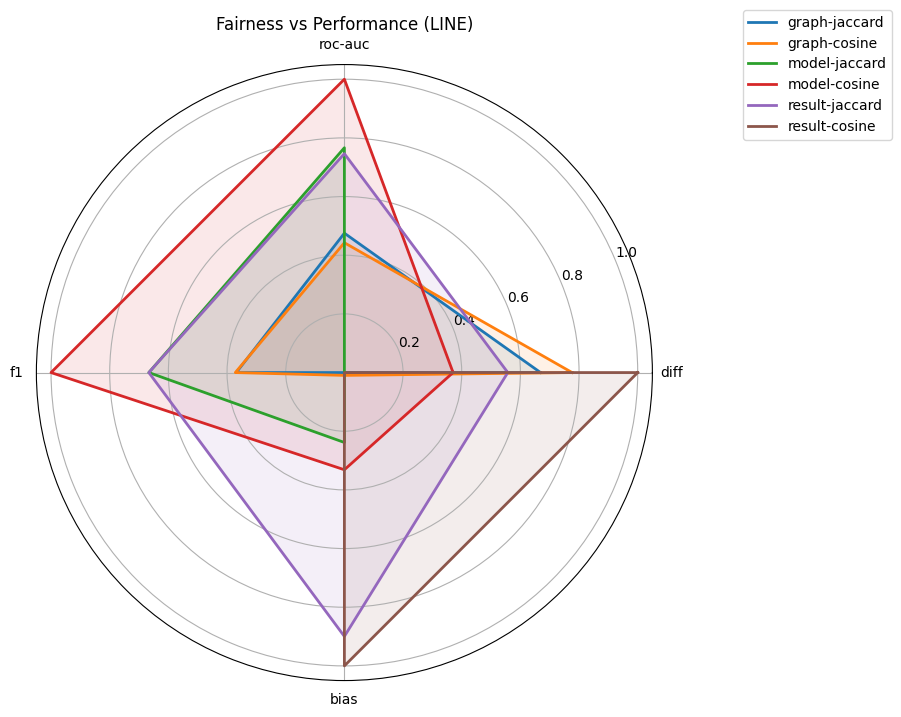

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# RUN EVALUATION
# =========================
results = []
configs = [
    ('jaccard', 'graph'), ('cosine', 'graph'),
    ('jaccard', 'model'), ('cosine', 'model'),
    ('jaccard', 'result'), ('cosine', 'result')
]

for metric, task in configs:
    r = evaluate(name='ppi', metric=metric, task=task)
    
    row = {
        'task': task,
        'metric': metric,
        'diff': float(r['diff']),
        'roc-auc': float(r['roc-auc'][1]),    # Lấy điểm ROC-AUC của mô hình sau khi giải độc (fair)
        'f1': float(r['f1'][1]),              # Lấy điểm F1 của mô hình sau khi giải độc (fair)
        'bias': float(r['bias']['test'][0])   # LINE trả về dict, lấy bias giảm được trên tập test
    }
    results.append(row)

# =========================
# DATAFRAME
# =========================
df = pd.DataFrame(results)
df['label'] = df['task'] + "-" + df['metric']
display(df)

# =========================
# BAR CHART
# =========================
# Sử dụng 4 chỉ số đặc trưng của LINE
metrics = ['diff', 'roc-auc', 'f1', 'bias']

x = np.arange(len(df))
width = 0.2

plt.figure(figsize=(15,6))
for i, metric in enumerate(metrics):
    plt.bar(x + i*width, df[metric], width=width, label=metric)

plt.xticks(x + width*1.5, df['label'], rotation=20)
plt.title("LINE Evaluation Metrics")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# RADAR CHART
# =========================
radar_df = df.copy()

# normalize để vẽ biểu đồ mạng nhện
for col in metrics:
    radar_df[col] = (radar_df[col] - radar_df[col].min()) / (radar_df[col].max() - radar_df[col].min())

categories = metrics
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for i in range(len(radar_df)):
    values = radar_df.loc[i, metrics].tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=2, label=radar_df.loc[i, 'label'])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.title("Fairness vs Performance (LINE)")
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.show()